In [2]:
import lightkurve as lk
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import phoebe
from phoebe import u
%matplotlib inline

/Users/mac/Library/Python/3.10/lib/python/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Connection to online passbands at http://tables.phoebe-project.org could not be established.  Check your internet connection or try again later (can manually call phoebe.list_online_passbands(refresh=True) to retry).  If the problem persists and you're using a Mac, you may need to update openssl (see http://phoebe-project.org/help/faq). Original error from urlopen: URLError <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:997)>


In [3]:
phoebe.update_all_passbands(local=True, content=None)

## TESS light curve plotting

In [ ]:
#search TESS light curves
J0045_coordinates = '0.18784 6.49496'
J0556_coordinates = '1.48694 -1.476551'
J0654_coordinates = '103.50797 75.457218'
lc = lk.search_lightcurve(J0654_coordinates, mission='TESS')#.download()
lc

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 20,2019,TESS-SPOC,1800,141465624,0.0
1,TESS Sector 19,2019,TESS-SPOC,1800,141465624,0.0
2,TESS Sector 26,2020,TESS-SPOC,1800,141465624,0.0
3,TESS Sector 47,2021,TESS-SPOC,600,141465624,0.0
4,TESS Sector 40,2021,TESS-SPOC,600,141465624,0.0
5,TESS Sector 59,2022,TESS-SPOC,200,141465624,0.0
6,TESS Sector 60,2022,TESS-SPOC,200,141465624,0.0
7,TESS Sector 53,2022,TESS-SPOC,600,141465624,0.0
8,TESS Sector 73,2023,TESS-SPOC,200,141465624,0.0


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/lightkurve/search.py:424: LightkurveWarning: Warning: 23 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


Text(0.5, 0, 'Frequency [1/d]')

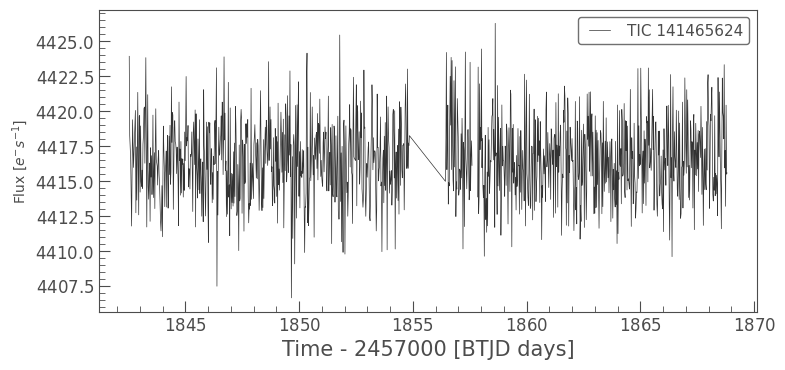

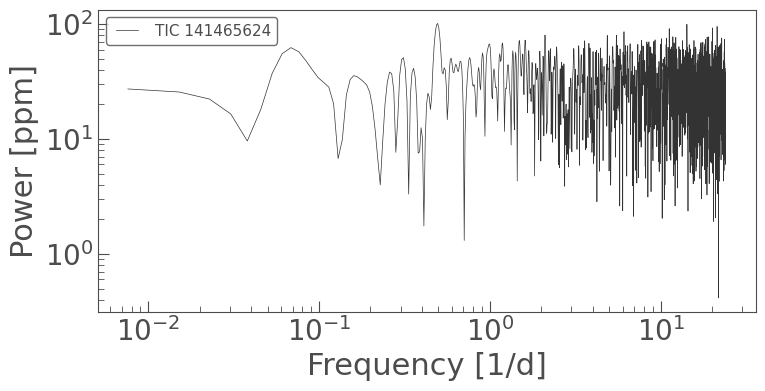

In [9]:
lightcurve = lc.download()
# start_time = 2462
# end_time = 2471
# filtered_lc = lightcurve[(lightcurve.time.value >= start_time) & (lightcurve.time.value <= end_time)]
# filtered_lc.plot()
lightcurve.plot()
# plt.xticks(fontsize = 20)
# plt.yticks(np.arange(740, 920, step=80), fontsize = 20)
# plt.xlabel('Time - 2457000 [BTJD days]', fontsize = 22)
plt.ylabel('Flux [$e^{-} s^{-1}$]', fontsize = 10)
# plt.xlim(2462,2470.5)
# plt.ylim(220,270)
pg = lightcurve.normalize(unit='ppm').to_periodogram()
pg.plot(scale='log')
plt.xticks(fontsize = 20)
plt.yticks( fontsize = 20)
plt.ylabel('Power [ppm]', fontsize = 22)
plt.xlabel('Frequency [1/d]', fontsize = 22)
# plt.savefig('/Users/mac/Desktop/cassi/light_curves/J065401.91+752725.9/TESS/periodogram.png')

In [25]:
pg.show_properties()
period = pg.period_at_max_power

lightkurve.Periodogram properties:
      Attribute         Description   Units
---------------------- -------------- -----
                nterms              1      
              targetid       24824445      
          default_view      frequency      
                 label   TIC 24824445      
             ls_method           fast      
frequency_at_max_power         0.1841 1 / d
             max_power        665.531   ppm
               nyquist        23.9999 1 / d
   period_at_max_power         5.4323     d
             frequency  array (2607,) 1 / d
                period  array (2607,)     d
                 power  array (2607,)   ppm
                  meta <class 'dict'>      


In [26]:
period

<Quantity 5.43231544 d>

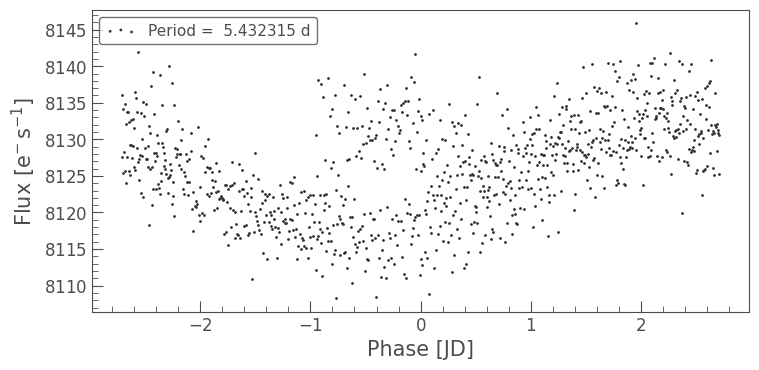

In [16]:
lightcurve.fold(period).scatter(label=fr'Period = {period: 5f}');
# plt.xticks(np.arange(-1, 1, step=0.3), fontsize = 20)
# plt.yticks(np.arange(4406, 4428, step=5), fontsize = 20)
# plt.xlabel('Phase', fontsize = 30)
# plt.ylabel('Flux [$e^{-} s^{-1}$]', fontsize = 30)